# Data Visualization -- Module 2, Class 3

In this notebook you will create 5 types of visualizations from the Superstore dataset:

1. Histogram (distribution of Sales)
2. Boxplot (Profit distribution and outliers)
3. Bar chart (Sales by Category)
4. Correlation heatmap
5. Time series (monthly sales trend)

All 5 are pre-built. At the end, you create 2 additional plots on your own.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Consistent styling
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

In [4]:
# Load dataset (same as data prep lab)
url = "https://raw.githubusercontent.com/dsrscientist/dataset1/master/superstore.csv"

try:
    df = pd.read_csv(url, encoding='latin-1')
    print(f"Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
except Exception as e:
    print(f"URL failed ({e}). Upload your CSV manually.")
    from google.colab import files
    uploaded = files.upload()
    filename = list(uploaded.keys())[0]
    df = pd.read_csv(filename, encoding='latin-1')
    print(f"Loaded: {df.shape[0]} rows, {df.shape[1]} columns")

df.head(3)

URL failed (HTTP Error 404: Not Found). Upload your CSV manually.


Saving SampleSuperstore.csv to SampleSuperstore.csv
Loaded: 10800 rows, 21 columns


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2.0,0.0,41.9136
1,2,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3.0,0.0,219.5820
2,3,CA-2017-138688,6/12/2017,6/16/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2.0,0.0,6.8714


In [5]:
# Quick data prep: convert date columns
# Identify date-like columns and convert
date_cols = [c for c in df.columns if 'date' in c.lower()]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')
    print(f"Converted {col} to datetime")

# Identify key column names (varies by dataset version)
print(f"\nColumns: {list(df.columns)}")

Converted Order Date to datetime
Converted Ship Date to datetime

Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


---
## 1. Histogram: Distribution of Sales

A histogram shows how values are distributed. Is the data symmetric? Skewed? Are there clusters?

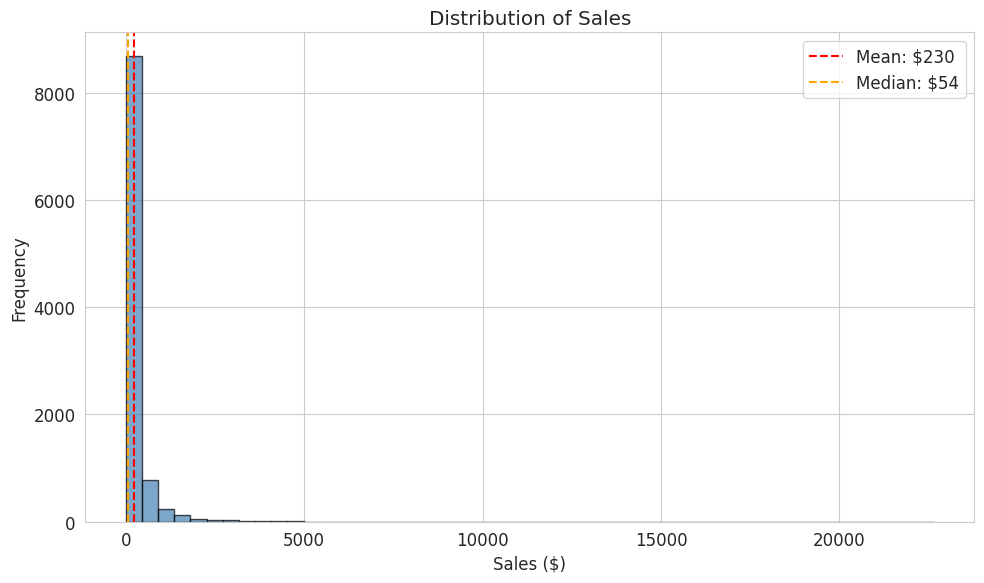

Interpretation: The distribution is right-skewed -- most orders are small,
with a long tail of high-value orders. Mean > Median confirms the skew.


In [6]:
# Find the sales column (may be 'Sales' or 'sales')
sales_col = [c for c in df.columns if 'sales' in c.lower()][0]

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df[sales_col], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax.set_xlabel('Sales ($)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Sales')
ax.axvline(df[sales_col].mean(), color='red', linestyle='--', label=f'Mean: ${df[sales_col].mean():,.0f}')
ax.axvline(df[sales_col].median(), color='orange', linestyle='--', label=f'Median: ${df[sales_col].median():,.0f}')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Interpretation: The distribution is right-skewed -- most orders are small,")
print(f"with a long tail of high-value orders. Mean > Median confirms the skew.")

---
## 2. Boxplot: Profit Distribution

A boxplot shows the quartiles (25th, 50th, 75th percentile) and outliers.

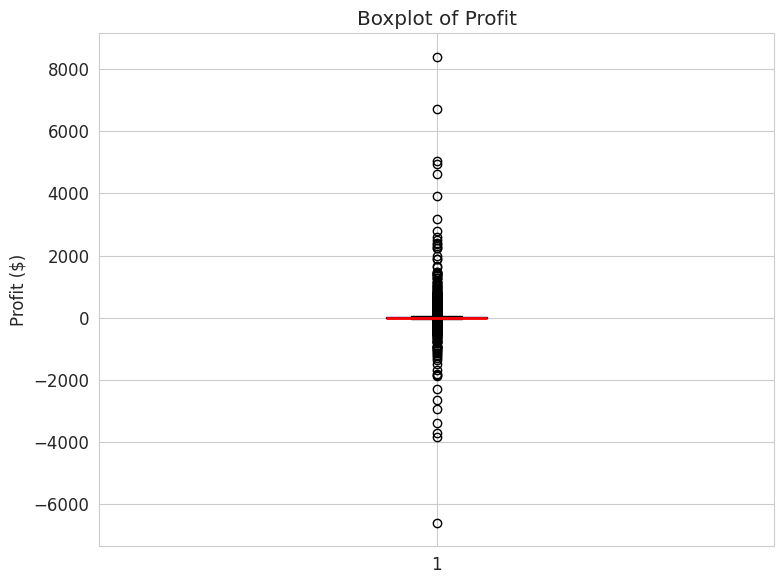

Q1: 1.73 | Q3: 29.36 | IQR: 27.64
Outlier boundaries: [-39.72, 70.82]
Number of outliers: 1881 (17.4% of data)


In [7]:
profit_col = [c for c in df.columns if 'profit' in c.lower()][0]

fig, ax = plt.subplots(figsize=(8, 6))
bp = ax.boxplot(df[profit_col].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='navy'),
                medianprops=dict(color='red', linewidth=2))
ax.set_ylabel('Profit ($)')
ax.set_title('Boxplot of Profit')
plt.tight_layout()
plt.show()

# Compute IQR for outlier boundaries
Q1 = df[profit_col].quantile(0.25)
Q3 = df[profit_col].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
n_outliers = ((df[profit_col] < lower_bound) | (df[profit_col] > upper_bound)).sum()

print(f"Q1: {Q1:,.2f} | Q3: {Q3:,.2f} | IQR: {IQR:,.2f}")
print(f"Outlier boundaries: [{lower_bound:,.2f}, {upper_bound:,.2f}]")
print(f"Number of outliers: {n_outliers} ({n_outliers/len(df):.1%} of data)")

---
## 3. Bar Chart: Sales by Category

Compare total sales across product categories.

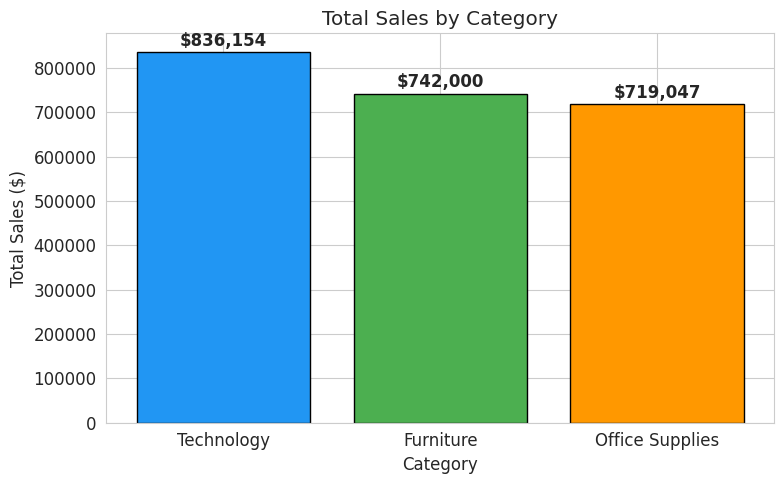

In [8]:
category_col = [c for c in df.columns if 'category' in c.lower()]
# Use the first match (usually 'Category', not 'Sub-Category')
cat_col = category_col[0] if category_col else None

if cat_col:
    cat_sales = df.groupby(cat_col)[sales_col].sum().sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(cat_sales.index, cat_sales.values, color=['#2196F3', '#4CAF50', '#FF9800'],
                  edgecolor='black')

    # Add value labels on bars
    for bar, val in zip(bars, cat_sales.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
                f'${val:,.0f}', ha='center', va='bottom', fontweight='bold')

    ax.set_xlabel('Category')
    ax.set_ylabel('Total Sales ($)')
    ax.set_title('Total Sales by Category')
    plt.tight_layout()
    plt.show()
else:
    print("No 'Category' column found. Check column names above.")

---
## 4. Correlation Heatmap

Shows how numerical features relate to each other. Values range from -1 (perfect negative) to +1 (perfect positive).

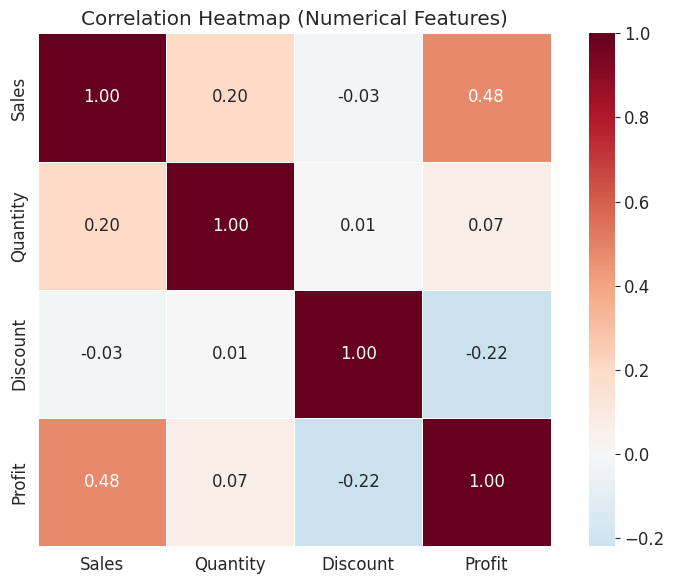

Interpretation:
- Look for strong positive correlations (close to +1): features that move together.
- Look for strong negative correlations (close to -1): features that move opposite.
- Remember: correlation does not imply causation.


In [9]:
# Select numerical columns for correlation
num_df = df.select_dtypes(include=[np.number])

# Drop ID-like columns (Row ID, Postal Code, etc.) that are not meaningful for correlation
id_like = [c for c in num_df.columns if any(kw in c.lower() for kw in ['id', 'postal', 'code', 'zip'])]
num_df = num_df.drop(columns=id_like, errors='ignore')

corr_matrix = num_df.corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap (Numerical Features)')
plt.tight_layout()
plt.show()

print("Interpretation:")
print("- Look for strong positive correlations (close to +1): features that move together.")
print("- Look for strong negative correlations (close to -1): features that move opposite.")
print("- Remember: correlation does not imply causation.")

---
## 5. Time Series: Monthly Sales Trend

Track how total sales change over time. Look for seasonality and trends.

/tmp/ipykernel_3342/3898767314.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.set_index(odate)[sales_col].resample('M').sum()


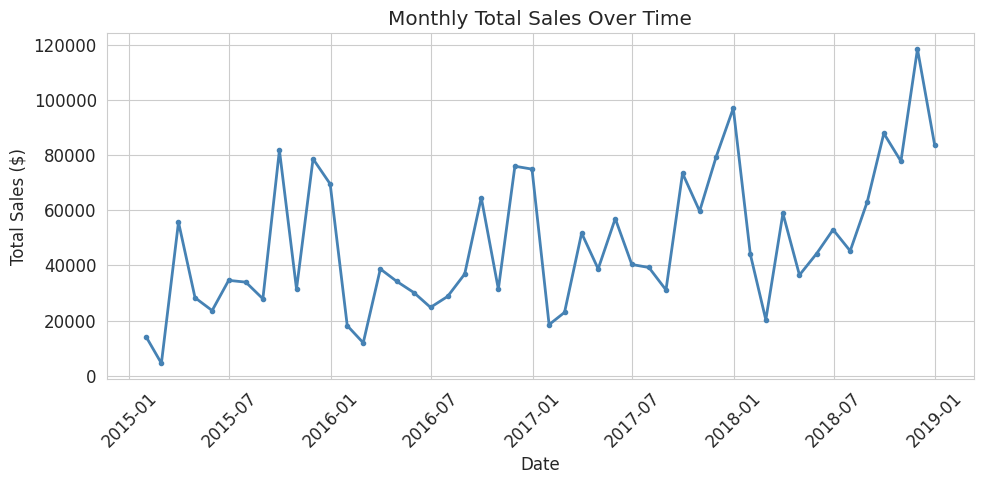

Look for:
- Overall trend (going up, down, or flat?)
- Seasonal patterns (spikes at certain times of year?)
- Anomalies (sudden drops or spikes?)


In [21]:
# Find the order date column
order_date_col = [c for c in df.columns if 'order' in c.lower() and 'date' in c.lower()]

if order_date_col:
    odate = order_date_col[0]

    # Resample to monthly totals
    monthly_sales = df.set_index(odate)[sales_col].resample('M').sum()

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(monthly_sales.index, monthly_sales.values, color='steelblue',
            linewidth=2, marker='o', markersize=3)
    ax.set_xlabel('Date')
    ax.set_ylabel('Total Sales ($)')
    ax.set_title('Monthly Total Sales Over Time')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

    print("Look for:")
    print("- Overall trend (going up, down, or flat?)")
    print("- Seasonal patterns (spikes at certain times of year?)")
    print("- Anomalies (sudden drops or spikes?)")
else:
    print("No order date column found. Check column names.")

---
## TODO: Create 2 Additional Plots

Create 2 plots that were NOT shown above. Some ideas:
- Scatter plot of Sales vs Profit
- Bar chart of Sales by Region
- Pie chart of order count by Segment (Consumer, Corporate, Home Office)
- Violin plot or histogram of Discount distribution
- Stacked bar chart by Category and Sub-Category

For each plot:
1. Write the code
2. Add title and axis labels
3. Write 2-3 sentences of interpretation in a markdown cell below the plot

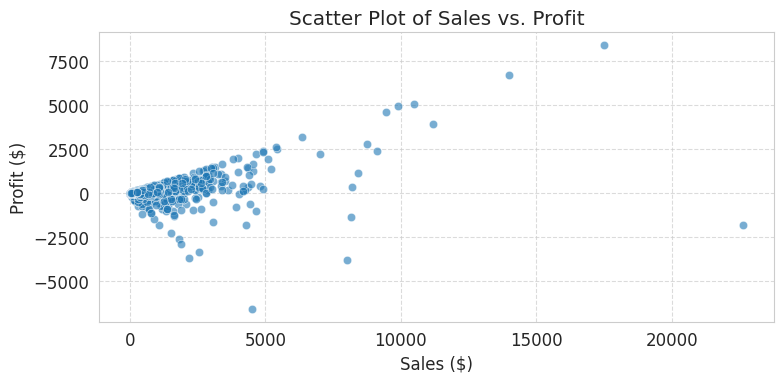

In [20]:
plt.figure(figsize=(8, 4))
sns.scatterplot(x='Sales', y='Profit', data=df, alpha=0.6)
plt.title('Scatter Plot of Sales vs. Profit')
plt.xlabel('Sales ($)')
plt.ylabel('Profit ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

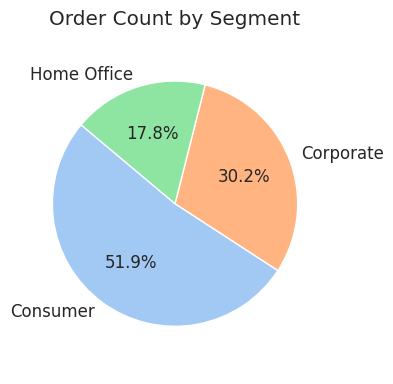

In [19]:
# TODO: Plot 2
# Your code here:
segment_counts = df['Segment'].value_counts()

plt.figure(figsize=(4, 4))
plt.pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Order Count by Segment')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

*TODO: Write your interpretation of Plot 2 here.*

---
## Reflection

Answer in a text cell below:

1. The Sales histogram is right-skewed. Why does this happen in retail data? What would it mean if it were perfectly normal?
2. You found outliers in Profit. Should you remove them? What information might you lose?
3. If Discount and Profit have a negative correlation, does that mean the company should stop giving discounts?